<a href="https://colab.research.google.com/github/pranojit9/Special-Study-in-Information-and-Communication-Technology-Roll-2671504-Pranojit_Roy/blob/main/Coding_Assignment_1/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       DISEASE PREDICTION USING MACHINE LEARNING

Dataset: Breast Cancer Wisconsin Diagnostic Dataset
Number of Samples : 569
Number of Features: 30

Target Classes:
0 = Benign
1 = Malignant
             DATA PREPROCESSING

Missing Values: 0
Duplicate Rows : 0

Class Distribution:
Target
Benign       357
Malignant    212
Name: count, dtype: int64

Training Samples: 455
Testing Samples : 114

Preprocessing completed successfully.
                 MODEL EVALUATION RESULTS


,Model,Accuracy,Precision,Recall,F1-score,Specificity
0,Logistic Regression,96.49%,97.50%,92.86%,95.12%,98.61%
1,Random Forest,96.49%,100.00%,90.48%,95.00%,100.00%
2,SVM,97.37%,100.00%,92.86%,96.30%,100.00%


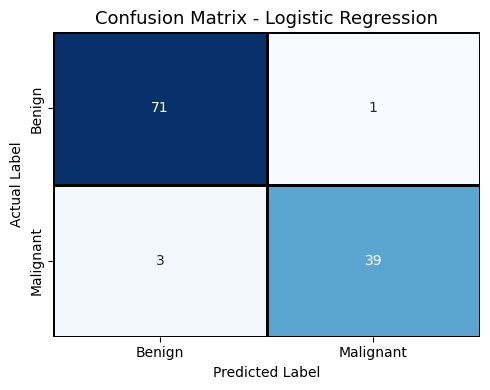

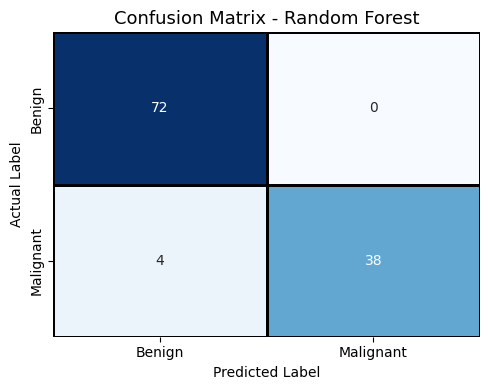

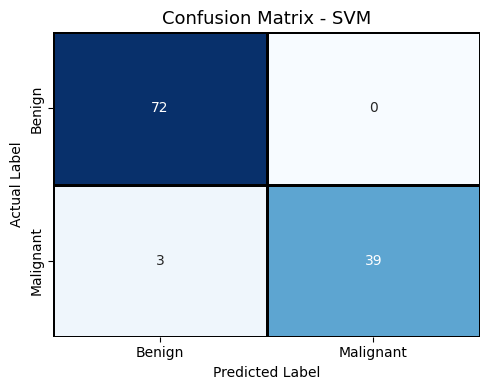


CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


CLASSIFICATION REPORT - SVM
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg   

,Model,Accuracy,Precision,Recall,F1-score,Specificity,Average Score
0,Logistic Regression,96.49%,97.50%,92.86%,95.12%,98.61%,96.12%
1,Random Forest,96.49%,100.00%,90.48%,95.00%,100.00%,96.39%
2,SVM,97.37%,100.00%,92.86%,96.30%,100.00%,97.30%



Best Overall Model : SVM
Average Score      : 97.30%


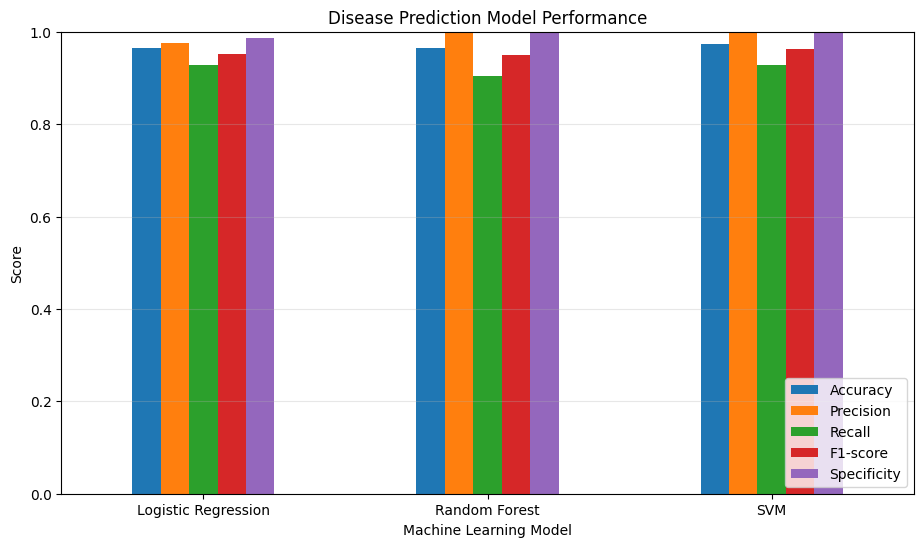

In [5]:
# ==========================================
# PART 1: IMPORT LIBRARIES & LOAD DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load Breast Cancer Wisconsin Diagnostic Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

# Convert labels:
# 0 = Benign, 1 = Malignant
y = (y == 0).astype(int)

print("=" * 60)
print("       DISEASE PREDICTION USING MACHINE LEARNING")
print("=" * 60)

print("\nDataset: Breast Cancer Wisconsin Diagnostic Dataset")
print("Number of Samples :", X.shape[0])
print("Number of Features:", X.shape[1])

print("\nTarget Classes:")
print("0 = Benign")
print("1 = Malignant")
# ==========================================
# PART 2: DATA PREPROCESSING
# ==========================================

print("=" * 60)
print("             DATA PREPROCESSING")
print("=" * 60)

# Missing values
print("\nMissing Values:", X.isnull().sum().sum())

# Duplicate rows
print("Duplicate Rows :", X.duplicated().sum())

# Class distribution
print("\nClass Distribution:")
print(y.value_counts().rename({0: "Benign", 1: "Malignant"}))

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling for Logistic Regression and SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))

print("\nPreprocessing completed successfully.")
# ==========================================
# PART 3: MODEL IMPLEMENTATION
# ==========================================
# ==========================================
# PART 4: MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------
# 1. Calculate Evaluation Metrics
# ------------------------------------------

results = []

for name, pred in predictions.items():

    # Confusion Matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    specificity = tn / (tn + fp)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        specificity
    ])


# ------------------------------------------
# 2. Create Results Table
# ------------------------------------------

results = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Specificity"
])

print("=" * 70)
print("                 MODEL EVALUATION RESULTS")
print("=" * 70)

display(
    results.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-score": "{:.2%}",
        "Specificity": "{:.2%}"
    })
)


# ------------------------------------------
# 3. Confusion Matrix Design
# ------------------------------------------

for name, pred in predictions.items():

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"],
        cbar=False,
        linewidths=1,
        linecolor="black"
    )

    plt.title(f"Confusion Matrix - {name}", fontsize=13)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()


# ------------------------------------------
# 4. Classification Reports
# ------------------------------------------

for name, pred in predictions.items():

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            pred,
            target_names=["Benign", "Malignant"]
        )
    )
# ==========================================
# PART 5: FINAL COMPARISON
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Specificity"
]

# Calculate average performance
results["Average Score"] = results[metrics].mean(axis=1)

# Find best model
best_index = results["Average Score"].idxmax()
best_model = results.loc[best_index, "Model"]
best_score = results.loc[best_index, "Average Score"]

print("=" * 60)
print("              FINAL RESULTS")
print("=" * 60)

display(results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "Specificity": "{:.2%}",
    "Average Score": "{:.2%}"
}))

print("\nBest Overall Model :", best_model)
print("Average Score      :", f"{best_score:.2%}")
# ==========================================
# MODEL COMPARISON GRAPH
# ==========================================

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Disease Prediction Model Performance")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()